# SafePath — Edge Safety Score & Routing

---

## Context — How Each Score Was Built

Before this notebook runs, four feature scores were computed and attached to
every street edge in the San Diego OSM walking network. Each score is a number
between 0 and 1 where **higher = safer or more comfortable** for a pedestrian.

| Score | Range | How it was computed | Source data |
|---|---|---|---|
| `crime_score_day` | 0–1 | SDPD incidents within 100 m of the edge. Each incident has a `severity_score` encoding how serious the crime is and how directly it threatens a pedestrian. Scores are summed, log-normalized, and flipped so 1 = no crime. Daytime incidents only (6 am–8 pm). | SDPD calls for service 2023–2025 |
| `crime_score_night` | 0–1 | Same as above but nighttime incidents only (9 pm–5 am). | SDPD calls for service 2023–2025 |
| `light_score` | 0–1 | Count of active City of San Diego streetlights within 30 m of the edge, normalized by the highest count across all edges. Higher = more streetlights = better lit. 99.99% of edges have a real score. | SD City streetlight inventory |
| `walk_score` | 0–1 | EPA National Walkability Index (`NatWalkInd`, 1–20) for the census block group the edge midpoint falls in, normalized to 0–1. Measures destination density and foot traffic. ~35% of edges use 0.5 fallback (ocean, parks, military land). | EPA Walkability Index |
| `road_class_score` | 0–1 | OSM `highway` tag mapped to a fixed comfort score. Footway/pedestrian = 1.0, residential = 0.70, tertiary = 0.50, secondary = 0.35, primary = 0.20, motorway = 0.0. Unlisted tags = 0.5. | OpenStreetMap |

---

## Data Required

This notebook needs two files in `data/processed/`:

| File | What it contains |
|---|---|
| `data/processed/sd_walk_graph.graphml` | San Diego OSM walking network — nodes are intersections, edges are street segments with `length`, `name`, `highway`, and geometry |
| `data/processed/edge_scores.csv` | One row per edge `(u, v, key)` with the five score columns above |

Both files are on Google Drive. Download and place them in `data/processed/` before running.

---

## Goal Of This Notebook

**Step 1 — Safety score per edge.**
Combine the five feature scores into a single `safety_score` (0–1) using a
weighted average split by time of day:

```
Daytime  (6 am–8 pm):  crime=0.40, light=0.25, walk=0.20, road=0.15
Nighttime (9 pm–5 am): crime=0.35, light=0.35, walk=0.15, road=0.15
```

**Step 2 — Safety cost per edge.**
Convert `safety_score` into a routing cost NetworkX can minimize:

```
safety_cost = length × (1 + 8 × (1 − safety_score))
```

**Step 3 — Three routes.**
For any origin–destination pair, compute fastest, safest, and balanced.

---

## Understanding The Formulas — Read Before Running

### Why Safety Cost Is Calculated This Way

NetworkX finds the path that minimizes total cost. We can't feed it `safety_score`
directly because a higher score means *safer* — and NetworkX would then seek out
the most dangerous streets. The formula solves this in three steps:

**1. Flip the score:**
`(1 − safety_score)` converts the score so 0 = perfectly safe, 1 = maximally
dangerous. Now NetworkX is minimizing in the right direction.

**2. Amplify the difference:**
Without any multiplier, a safe edge (score 0.9) and a dangerous one (score 0.1)
would cost 1.1× and 1.9× their length — a difference too small to justify a detour.
Multiplying by 8 widens that gap to 1.8× vs 8.2× — now the router has a genuine
reason to go around the dangerous street.

**3. Keep physical distance meaningful:**
Adding 1 before multiplying by length ensures a perfectly safe edge (score=1.0)
still costs exactly its real physical length. Without this, the formula would
give safe streets a cost of 0 — the router could treat safe streets as free.

The result:

| `safety_score` | `safety_cost` |
|---|---|
| 1.0 — perfect | 1× length |
| 0.75 | 3× length |
| 0.5 — average | 5× length |
| 0.25 | 7× length |
| 0.0 — worst | 9× length |

---

### Why 8 Might Not Be The Right Multiplier

The multiplier of 8 is a **starting point, not a final answer**. It was chosen
based on early testing with the score distribution. Whether it is right depends
on how spread out the safety scores actually are across the network.

**If the multiplier is too low (e.g. 3–4):**
The cost difference between a safe and a dangerous edge stays small. The router
will barely deviate from the fastest route — the safety signal is drowned out
by physical distance. The safest and fastest routes will look nearly identical
on the map.

**If the multiplier is too high (e.g. 14–16):**
The router aggressively avoids even mildly lower-scoring streets. The safest
route can end up 2–3× longer than the fastest. A pedestrian who is offered a
route that adds 20 minutes to avoid a block that is only slightly less safe
is unlikely to follow it — the app loses credibility.

**How to judge if 8 is right for your data:**
Run the fastest and safest routes on a few test pairs. If the routes are
identical, raise the multiplier. If safest is more than 25–30% longer than
fastest, lower it. The right value is where the safest route takes a clear
but reasonable detour around genuinely dangerous streets.

---

### Why The Balanced Route Is Calculated This Way

```
balanced_cost = alpha × length + (1 − alpha) × safety_cost
```

The formula is a linear blend between two extremes:

| alpha | What happens |
|---|---|
| 1.0 | Formula collapses to just `length` — identical to fastest |
| 0.5 | Both contribute equally — current default |
| 0.0 | Formula collapses to just `safety_cost` — identical to safest |

This formula is intentionally simple. It is easy to explain: alpha is a dial
between speed and safety. A user who wants mostly safe but not too long tries
alpha=0.3. A user who just wants a slight improvement tries alpha=0.7.

**This is a suggestion, not a fixed design.** Some alternatives worth trying:

- `sqrt(length × safety_cost)` — geometric mean, penalizes routes that are
  *both* long and dangerous more aggressively
- Use a lower multiplier for balanced than for safest (e.g. 4 for balanced,
  8 for safest) — this naturally produces a gentler middle route without
  needing alpha at all
- Weighted crime-only avoidance for balanced and full score for safest

---

### What Changing These Numbers Does To The Path

| Change | Effect on routing | When to try it |
|---|---|---|
| Raise safety_cost multiplier | Router avoids dangerous streets more aggressively, adds more walking distance | Routes barely differ from fastest |
| Lower safety_cost multiplier | Router stays closer to the direct path, less sensitive to score differences | Safest route is unreasonably long |
| Lower alpha (toward 0) | Balanced behaves more like safest — safety dominates | Users who prioritize safety over time |
| Raise alpha (toward 1) | Balanced behaves more like fastest — barely deviates | Users who want a slight safety improvement only |
| Both high multiplier and low alpha | Extreme safety focus — path may go well out of its way | Testing the outer limits of the scoring |
| Both low multiplier and high alpha | Almost identical to fastest — scoring barely influences the route | Checking if scores are differentiated enough |

The multiplier and alpha interact: a high multiplier with alpha=0.5 often
produces the same route as a lower multiplier with alpha=0.0. Start with
multiplier=8 and alpha=0.5, then move one knob at a time and observe what
changes before adjusting both together.


In [111]:
import os
import json

import numpy as np
import pandas as pd
import geopandas as gpd

import osmnx as ox                          # load/save graphml, nearest_nodes
import networkx as nx                       # shortest_path, graph traversal

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D         # custom legend entries for route maps
from shapely.geometry import LineString     # fallback edge geometry for plotting
from datetime import datetime               # system clock for day/night detection

from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

In [112]:
G = ox.load_graphml('../data/processed/sd_walk_graph.graphml')
scores = pd.read_csv('../data/processed/edge_scores.csv')
print(f'Graph edges: {G.number_of_edges():,}')
print(f'Score rows:  {len(scores):,}')

Graph edges: 684,012
Score rows:  684,012


In [113]:
for u,v,key, data in G.edges(keys=True, data=True):
    idx = (u,v,key)
    if idx in scores.index:
        data["safety_cost"]       = scores.loc[idx, "safety_cost"]
        data["safety_score"]      = scores.loc[idx, "safety_score"]
        data["crime_score_day"]   = scores.loc[idx, "crime_score_day"]
        data["crime_score_night"] = scores.loc[idx, "crime_score_night"]
        data["light_score"]       = scores.loc[idx, "light_score"]
        data["walk_score"]        = scores.loc[idx, "walk_score"]
        data["road_class_score"]  = scores.loc[idx, "road_class_score"]

In [114]:
from datetime import datetime

hour = datetime.now().hour
IS_NIGHT = hour >= 21 or hour <= 5
print(f'Current hour: {hour} → {"Night" if IS_NIGHT else "Day"} mode')

Current hour: 13 → Day mode


In [115]:
if IS_NIGHT:
    W_CRIME = 0.50   # crime_score_night
    W_LIGHT = 0.15   # light_score (reduced — low variation in data)
    W_WALK  = 0.20   # walk_score
    W_ROAD  = 0.15   # road_class_score
else:
    W_CRIME = 0.50   # crime_score_day
    W_LIGHT = 0.10   # light_score (reduced — low variation in data)
    W_WALK  = 0.25   # walk_score
    W_ROAD  = 0.15   # road_class_score

crime_col = 'crime_score_night' if IS_NIGHT else 'crime_score_day'

scores['safety_score'] = (
    W_CRIME * scores[crime_col] +
    W_LIGHT * scores['light_score'] +
    W_WALK  * scores['walk_score'] +
    W_ROAD  * scores['road_class_score']
)

print(scores['safety_score'].describe().round(3))

count    684012.000
mean          0.707
std           0.089
min           0.142
25%           0.668
50%           0.717
75%           0.770
max           0.905
Name: safety_score, dtype: float64


In [200]:
# Build a lookup dict from (u, v, key) → safety_score for fast access
score_lookup = {
    (row.u, row.v, row.key): row.safety_score
    for row in scores.itertuples()
}

for u, v, k, data in G.edges(keys=True, data=True): 
    score = score_lookup.get((u, v, k), 0.5) # fallback to neutral
    data['safety_score'] = score 
    data['safety_cost']  = data.get('length', 0) * (1 + 8 * (1 - score))

print(f"Edges with safety_score written: {G.number_of_edges():,}")

Edges with safety_score written: 684,012


In [127]:
def get_routes(address_start, address_end, G):
    geolocator = Nominatim(user_agent='safepath_ucsd_2026')

    start = geolocator.geocode(address_start)
    end   = geolocator.geocode(address_end)

    if start is None or end is None:
        raise ValueError(f'Could not geocode: {address_start!r} or {address_end!r}')

    orig = ox.nearest_nodes(G, X=start.longitude, Y=start.latitude)
    dest = ox.nearest_nodes(G, X=end.longitude,   Y=end.latitude)

    def balanced_weight(u, v, d):
        alpha = 0.5
        return alpha * d.get('length', 0) + alpha * d.get('safety_cost', d.get('length', 0))
        
    
    return {
        'fastest':  nx.shortest_path(G, orig, dest, weight='length'),
        'safest':   nx.shortest_path(G, orig, dest, weight='safety_cost'),
        'balanced': nx.shortest_path(G, orig, dest, weight=balanced_weight),
    }

In [211]:
def get_routes_by_coord(start, end, G):
    orig = ox.nearest_nodes(G, X=start[1], Y=start[0])
    dest = ox.nearest_nodes(G, X=end[1],   Y=end[0])

    def balanced_weight(u, v, d):
        d = d[0]
        score = d.get('safety_score', 0.5)
        length = d.get('length', 0)
        return length * (1 + 3 * (1 - score))
    
    return {
        'fastest':  nx.shortest_path(G, orig, dest, weight='length'),
        'safest':   nx.shortest_path(G, orig, dest, weight='safety_cost'),
        'balanced': nx.shortest_path(G, orig, dest, weight=balanced_weight),
    }

In [205]:
def route_total_cost(G, route, weight):
    return sum(G[u][v][0].get(weight, 0) for u, v in zip(route[:-1], route[1:]))

In [206]:
def display_route_info(G, route_fastest, route_safest, route_balanced, exact_route):
    print(f"\nFastest route:  {len(route_fastest)}  nodes")
    print(f"Safest route:   {len(route_safest)}  nodes")
    print(f"Balanced route: {len(route_balanced)} nodes")

    
    print(f"\n\nFastest  — Length:      {route_total_cost(G, route_fastest,  'length'):.1f}m")
    print(f"Fastest  - Safety Cost: {route_total_cost(G, route_fastest,  'safety_cost'):.1f}")
    
    print(f"\nSafest   — Length:      {route_total_cost(G, route_safest,   'length'):.1f}m  (+{route_total_cost(G, route_safest, 'length') - route_total_cost(G, route_fastest, 'length'):.1f}m detour)")
    print(f"Safest   — Safety Cost: {route_total_cost(G, route_safest,   'safety_cost'):.1f}")
    
    print(f"\nBalanced — Length:      {route_total_cost(G, route_balanced, 'length'):.1f}m")
    print(f"Balanced - Safety Cost: {route_total_cost(G, route_balanced, 'safety_cost'):.1f}")

    if exact_route:
        for label, route in [("Fastest", route_fastest), ("Safest", route_safest), ("Balanced", route_balanced)]:
            print(f"\nStreets on {label} route:")
            for u, v in zip(route[:-1], route[1:]):
                data = G[u][v][0]
                print(f"  {str(data.get('name', 'Unnamed')):35s} | "
                      f"safety_score={data.get('safety_score', 0):.3f} | "
                      f"highway={str(data.get('highway', '?')):15s} | "
                      f"safety_cost={data.get('safety_cost', 0):.1f}")

In [207]:
# Convert each route to a GeoDataFrame of edge geometries
def route_to_gdf(G, route):
    geoms = []
    for u, v in zip(route[:-1], route[1:]):
        data = G[u][v][0]
        if "geometry" in data:
            geoms.append(data["geometry"])
        else:
            geoms.append(LineString([(G.nodes[u]["x"], G.nodes[u]["y"]),
                                     (G.nodes[v]["x"], G.nodes[v]["y"])]))
    return gpd.GeoDataFrame(geometry=geoms, crs="EPSG:4326")

def display_route(G, route_fastest, route_safest, route_balanced):
    
    # Build route bbox for zoom 
    all_route_nodes = set(route_fastest + route_safest + route_balanced)
    xs = [G.nodes[n]["x"] for n in all_route_nodes]
    ys = [G.nodes[n]["y"] for n in all_route_nodes]
    pad_x = (max(xs) - min(xs)) * 0.25
    pad_y = (max(ys) - min(ys)) * 0.25

    gdf_fastest  = route_to_gdf(G, route_fastest)
    gdf_safest   = route_to_gdf(G, route_safest)
    gdf_balanced = route_to_gdf(G, route_balanced)

    # Plot — widest route drawn first, narrowest last so all are always visible
    fig, ax = ox.plot_graph(
        G,
        node_size=0,
        bgcolor="#0d1117",
        edge_color="#2d3748",
        edge_linewidth=0.4,
        edge_alpha=0.6,
        figsize=(14, 14),
        show=False,
        close=False,
    )

    gdf_fastest.plot( ax=ax, color="#FF6B35", linewidth=7,   linestyle="solid",  alpha=0.85)
    gdf_safest.plot(  ax=ax, color="#4ECDC4", linewidth=4,   linestyle="solid",  alpha=0.95)
    gdf_balanced.plot(ax=ax, color="#C9B8FF", linewidth=2.5, linestyle="dashed", alpha=1.0)
    
    ax.set_xlim(min(xs) - pad_x, max(xs) + pad_x)
    ax.set_ylim(min(ys) - pad_y, max(ys) + pad_y)
    
    ax.set_title(
        "SafePath Route Comparison — Mission Hills → Gaslamp Quarter",
        color="white",
        fontsize=15,
        fontweight="bold",
        pad=14,
    )
    
    legend_elements = [
        Line2D([0], [0], color="#FF6B35", linewidth=4, linestyle="solid",
               label=f"Fastest  — {route_total_cost(G, route_fastest, 'length'):.0f} m"),
        Line2D([0], [0], color="#4ECDC4", linewidth=3, linestyle="solid",
               label=f"Safest   — {route_total_cost(G, route_safest, 'length'):.0f} m  (+{route_total_cost(G, route_safest, 'length') - route_total_cost(G, route_fastest, 'length'):.0f} m detour)"),
        Line2D([0], [0], color="#C9B8FF", linewidth=2.5, linestyle="dashed",
               label=f"Balanced — {route_total_cost(G, route_balanced, 'length'):.0f} m"),
    ]
    ax.legend(
        handles=legend_elements,
        loc="lower right",
        framealpha=0.35,
        facecolor="#1a202c",
        edgecolor="#4a5568",
        labelcolor="white",
        fontsize=11,
    )
    
    plt.tight_layout()
    plt.show()


Fastest route:  119  nodes
Safest route:   141  nodes
Balanced route: 121 nodes


Fastest  — Length:      5957.8m
Fastest  - Safety Cost: 23079.1

Safest   — Length:      6645.6m  (+687.8m detour)
Safest   — Safety Cost: 21469.0

Balanced — Length:      6142.2m
Balanced - Safety Cost: 21758.2

Streets on Fastest route:
  Unnamed                             | safety_score=0.638 | highway=footway         | safety_cost=73.6
  Unnamed                             | safety_score=0.638 | highway=footway         | safety_cost=112.6
  Unnamed                             | safety_score=0.637 | highway=footway         | safety_cost=45.9
  Unnamed                             | safety_score=0.640 | highway=footway         | safety_cost=214.6
  Unnamed                             | safety_score=0.849 | highway=footway         | safety_cost=87.5
  Unnamed                             | safety_score=0.778 | highway=footway         | safety_cost=83.0
  Unnamed                             | safety_score

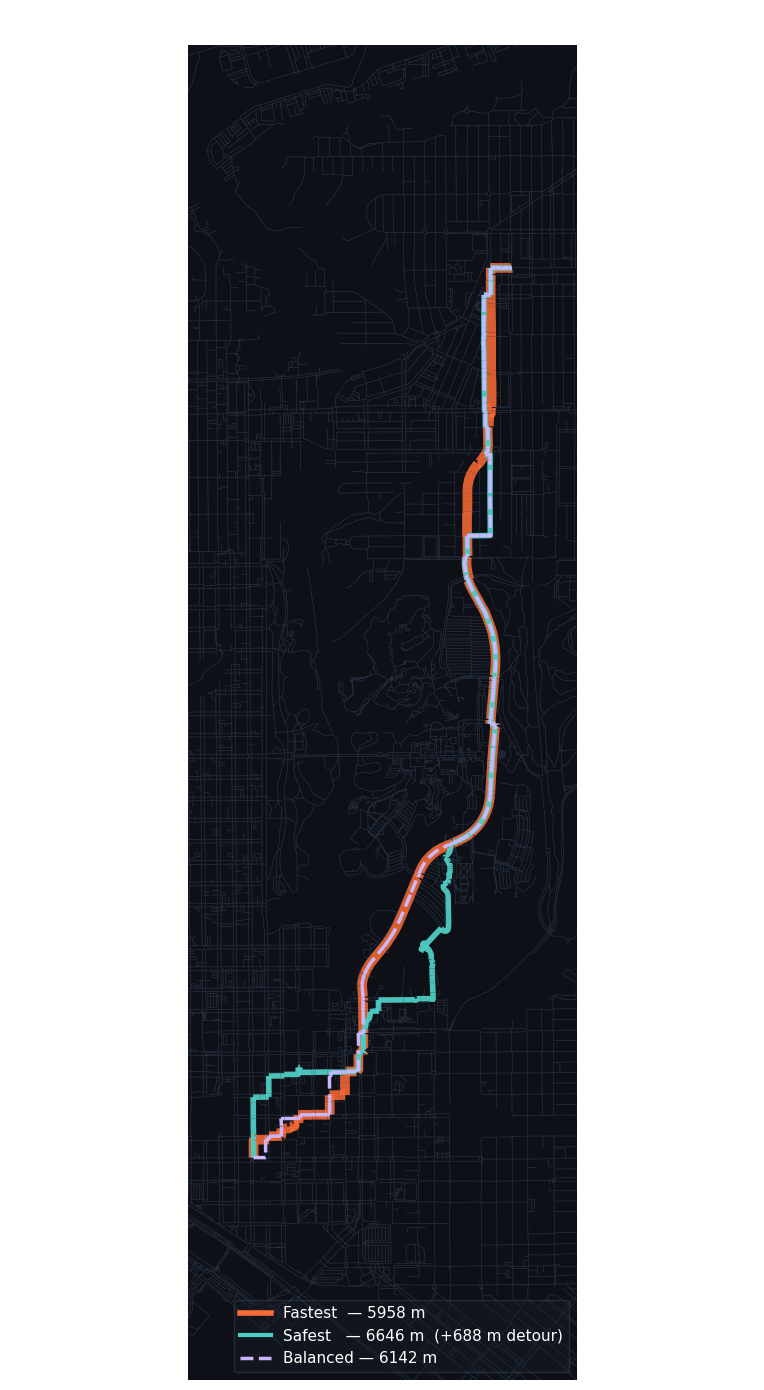

In [217]:
start = (32.7553, -117.1449)   # 1900 El Cajon Blvd area
end   = (32.7117, -117.1600)   # Market St downtown

routes = get_routes_by_coord(start, end, G)

route_fastest, route_safest, route_balanced = routes['fastest'], routes['safest'], routes['balanced']

display_route_info(G, route_fastest, route_safest, route_balanced, exact_route = True)
display_route(G, route_fastest, route_safest, route_balanced)